## Parallel Chains

In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict ,Annotated
from dotenv import load_dotenv
import os
from pydantic import BaseModel ,Field
import operator


In [3]:
load_dotenv()

True

In [4]:
api_key = os.getenv('GOOGLE_API_KEY')

In [5]:
model = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash',
    google_api_key = api_key
)

In [6]:
class EvulationSchema(BaseModel):
    feedback : str =  Field(description="Detailed feedback for the eassy")
    score : int = Field(description="Score out of 10 ",ge=0,le=10)
    

In [7]:
Structure_model = model.with_structured_output(EvulationSchema)

In [8]:
essay = """
    The Evolution of Artificial Intelligence in Economics

Artificial Intelligence (AI) has transformed from a theoretical concept into one of the most powerful forces shaping modern economies. Over the past several decades, AI has evolved from simple rule-based systems to advanced machine learning and deep learning models that influence industries, labor markets, productivity, and global economic structures. The evolution of AI has not only changed how businesses operate but has also redefined economic growth, competition, and innovation.

Early Development of AI in Economics

In its early stages during the mid-20th century, AI focused mainly on symbolic reasoning and basic automation. Economists initially used computers for statistical analysis and forecasting. Simple algorithms helped in modeling supply and demand, predicting trends, and analyzing financial data. However, these systems required manual programming and lacked the ability to learn from new data.

During the 1980s and 1990s, expert systems emerged. These systems were designed to simulate decision-making abilities in specific domains, such as credit scoring and risk assessment. Financial institutions began adopting AI-driven tools to evaluate loan applications and detect fraud. This marked the beginning of AI’s practical economic impact.

The Rise of Machine Learning and Big Data

The real transformation began in the 21st century with the rise of machine learning and the availability of big data. AI systems became capable of learning patterns from vast datasets without explicit programming. This significantly improved forecasting, pricing strategies, and consumer behavior analysis.

E-commerce platforms, financial markets, and multinational corporations began using AI to optimize supply chains, personalize marketing, and automate customer service. Algorithmic trading revolutionized stock markets by executing trades at speeds impossible for humans. Productivity increased as AI systems automated repetitive tasks in manufacturing and services.

AI and Labor Markets

One of the most significant economic impacts of AI has been on employment. Automation has replaced many routine and manual jobs, particularly in manufacturing and administrative sectors. At the same time, AI has created new opportunities in data science, robotics, software development, and AI research.

This shift has led to a demand for higher-skilled workers, emphasizing education and digital literacy. Economists debate whether AI will cause long-term unemployment or simply transform the nature of work. While some jobs disappear, new industries and roles continue to emerge, reflecting a pattern seen in previous technological revolutions.

AI and Economic Growth

AI contributes to economic growth by increasing productivity, improving efficiency, and fostering innovation. Businesses can reduce costs, enhance decision-making, and expand into global markets. Governments use AI for policy analysis, taxation systems, and public service management.

Countries investing heavily in AI research and infrastructure are gaining competitive advantages in the global economy. AI is becoming a key driver of national economic power, influencing trade, defense, and technological leadership.

Challenges and Ethical Concerns

Despite its benefits, AI presents economic challenges. Income inequality may widen if wealth generated by AI concentrates among technology owners and highly skilled workers. Small businesses may struggle to compete with large firms that can afford advanced AI systems.

There are also concerns about data privacy, cybersecurity, and ethical decision-making. Governments must create policies that balance innovation with regulation to ensure inclusive and sustainable economic growth.

"""

In [9]:
prmopt = f"evulate the language quailty of the following eassy and provide a feedback and assign the score out of 10\n{essay}"

Structure_model.invoke(prmopt)

EvulationSchema(feedback='The essay demonstrates excellent language quality. It is exceptionally well-structured, with a clear introduction, logical progression of ideas through distinct sections, and a concise conclusion. The vocabulary is precise and appropriate for the subject matter, effectively conveying complex economic and technological concepts without resorting to excessive jargon. Sentence structures are varied, contributing to readability and maintaining reader engagement. Grammatical accuracy and punctuation are consistently strong, with no noticeable errors. The essay maintains an objective and informative tone throughout, making it highly effective in explaining the evolution and impact of AI in economics.', score=9)

In [10]:
class UPSEstate(TypedDict):
    essay : str
    language_feedback : str
    analysis_feedback : str
    clarity_of_thought_feedback : str
    overall_feedback : str
    individual_score:Annotated[list[int],operator.add]
    average_score : float


In [11]:
def evulate_language(state:UPSEstate) ->UPSEstate:
    prompt = f"evulate the language quailty of the following eassy and provide a feedback and assign the score out of 10\n{state['essay']} "

    output = Structure_model.invoke(prompt)
    return {'language_feedback':output.feedback,'individual_score':[output.score]}



In [12]:
def evulate_analysis(state:UPSEstate) ->UPSEstate:
    prompt = f"evulate the Depth of analysis of the following eassy and provide a feedback and assign the score out of 10\n{state['essay']} "

    output = Structure_model.invoke(prompt)
    return {'analysis_feedback':output.feedback,'individual_score':[output.score]}



In [13]:
def evulate_thought(state:UPSEstate) ->UPSEstate:
    prompt = f"evulate the clarity of thought of the following eassy and provide a feedback and assign the score out of 10\n{state['essay']} "

    output = Structure_model.invoke(prompt)
    return {'clarity_of_thought_feedback':output.feedback,'individual_score':[output.score]}



In [22]:
def final_evuluation(state:UPSEstate) -> UPSEstate:
    # Summery feedback
    prompt = f"Based on the following feedback create a summeries feedback \n langaugage feedback - {state['language_feedback']} \n depth of analysis {state['analysis_feedback']} \n clarity of thought - {state['clarity_of_thought_feedback']}"

    final_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_score']) / len(state['individual_score'])
    return {'overall_feedback':final_feedback,'average_score':avg_score}

In [23]:
graph = StateGraph(UPSEstate)

graph.add_node('evualte_language',evulate_language)
graph.add_node('evualte_analysis',evulate_analysis)
graph.add_node('evulate_thought',evulate_thought)
graph.add_node('final_evuluation',final_evuluation)

graph.add_edge(START,"evualte_language")
graph.add_edge(START,"evualte_analysis")
graph.add_edge(START,"evulate_thought")

graph.add_edge("evualte_language","final_evuluation")
graph.add_edge("evualte_analysis","final_evuluation")
graph.add_edge("evulate_thought","final_evuluation")

graph.add_edge("final_evuluation",END)

workflow = graph.compile()

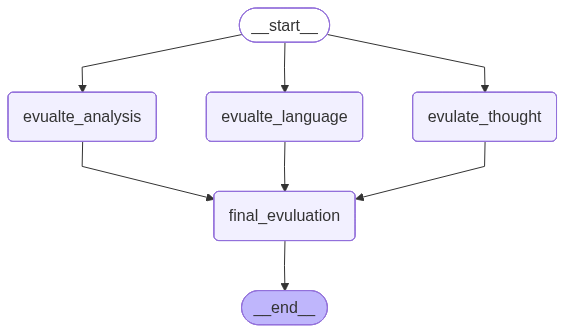

In [24]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [25]:
intial_state  = {
    "essay" : essay
}

workflow.invoke(intial_state)

{'essay': '\n    The Evolution of Artificial Intelligence in Economics\n\nArtificial Intelligence (AI) has transformed from a theoretical concept into one of the most powerful forces shaping modern economies. Over the past several decades, AI has evolved from simple rule-based systems to advanced machine learning and deep learning models that influence industries, labor markets, productivity, and global economic structures. The evolution of AI has not only changed how businesses operate but has also redefined economic growth, competition, and innovation.\n\nEarly Development of AI in Economics\n\nIn its early stages during the mid-20th century, AI focused mainly on symbolic reasoning and basic automation. Economists initially used computers for statistical analysis and forecasting. Simple algorithms helped in modeling supply and demand, predicting trends, and analyzing financial data. However, these systems required manual programming and lacked the ability to learn from new data.\n\nD